In [1]:
#import the telco churn data:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ** Dataset Cleaning & Exploration **

In [3]:
import os

df = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

# 'Churn' as target variable
y = df['Churn']
X = df.drop('Churn', axis=1)

# Convert X to a numpy array
X = X.to_numpy()

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("First 5 rows of X:\n", X[:5])
print("First 5 values of y:\n", y[:5])

Shape of features (X): (7043, 20)
Shape of target (y): (7043,)
First 5 rows of X:
 [['7590-VHVEG' 'Female' 0 'Yes' 'No' 1 'No' 'No phone service' 'DSL' 'No'
  'Yes' 'No' 'No' 'No' 'No' 'Month-to-month' 'Yes' 'Electronic check'
  29.85 '29.85']
 ['5575-GNVDE' 'Male' 0 'No' 'No' 34 'Yes' 'No' 'DSL' 'Yes' 'No' 'Yes'
  'No' 'No' 'No' 'One year' 'No' 'Mailed check' 56.95 '1889.5']
 ['3668-QPYBK' 'Male' 0 'No' 'No' 2 'Yes' 'No' 'DSL' 'Yes' 'Yes' 'No'
  'No' 'No' 'No' 'Month-to-month' 'Yes' 'Mailed check' 53.85 '108.15']
 ['7795-CFOCW' 'Male' 0 'No' 'No' 45 'No' 'No phone service' 'DSL' 'Yes'
  'No' 'Yes' 'Yes' 'No' 'No' 'One year' 'No' 'Bank transfer (automatic)'
  42.3 '1840.75']
 ['9237-HQITU' 'Female' 0 'No' 'No' 2 'Yes' 'No' 'Fiber optic' 'No' 'No'
  'No' 'No' 'No' 'No' 'Month-to-month' 'Yes' 'Electronic check' 70.7
  '151.65']]
First 5 values of y:
 0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object


In [4]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [5]:
#example of one:
print(X[:1])

[['7590-VHVEG' 'Female' 0 'Yes' 'No' 1 'No' 'No phone service' 'DSL' 'No'
  'Yes' 'No' 'No' 'No' 'No' 'Month-to-month' 'Yes' 'Electronic check'
  29.85 '29.85']]


In [6]:
first_customer = df.iloc[0]

# Prepare data for a new DataFrame to display the requested information
data = []
for col_name, value in first_customer.items():
    data.append({
        'Column Name': col_name,
        'Value': value,
        'Type': type(value).__name__
    })

# Create a DataFrame for better readability
result_df = pd.DataFrame(data)
print(result_df)

         Column Name             Value     Type
0         customerID        7590-VHVEG      str
1             gender            Female      str
2      SeniorCitizen                 0    int64
3            Partner               Yes      str
4         Dependents                No      str
5             tenure                 1    int64
6       PhoneService                No      str
7      MultipleLines  No phone service      str
8    InternetService               DSL      str
9     OnlineSecurity                No      str
10      OnlineBackup               Yes      str
11  DeviceProtection                No      str
12       TechSupport                No      str
13       StreamingTV                No      str
14   StreamingMovies                No      str
15          Contract    Month-to-month      str
16  PaperlessBilling               Yes      str
17     PaymentMethod  Electronic check      str
18    MonthlyCharges             29.85  float64
19      TotalCharges             29.85  

In [7]:
#make total charges a number, not str"
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df[['TotalCharges']].head())
print(df['TotalCharges'].dtype)

   TotalCharges
0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
float64


In [8]:
# See the unique vales for string-typed columns
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"Column '{col}': {df[col].unique()}")

Column 'customerID': ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Column 'gender': ['Female' 'Male']
Column 'Partner': ['Yes' 'No']
Column 'Dependents': ['No' 'Yes']
Column 'PhoneService': ['No' 'Yes']
Column 'MultipleLines': ['No phone service' 'No' 'Yes']
Column 'InternetService': ['DSL' 'Fiber optic' 'No']
Column 'OnlineSecurity': ['No' 'Yes' 'No internet service']
Column 'OnlineBackup': ['Yes' 'No' 'No internet service']
Column 'DeviceProtection': ['No' 'Yes' 'No internet service']
Column 'TechSupport': ['No' 'Yes' 'No internet service']
Column 'StreamingTV': ['No' 'Yes' 'No internet service']
Column 'StreamingMovies': ['No' 'Yes' 'No internet service']
Column 'Contract': ['Month-to-month' 'One year' 'Two year']
Column 'PaperlessBilling': ['Yes' 'No']
Column 'PaymentMethod': ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Column 'Churn': ['No' 'Yes']


In [9]:
#drop "customerID"
df = df.drop('customerID', axis=1)

In [10]:
#see where
print("Number of null values per column in df:")
print(df.isnull().sum())

Number of null values per column in df:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
# Convert 'Churn' to numerical (0 for No, 1 for Yes)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify categorical columns (object dtype) excluding 'customerID' which was already dropped
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

# Exclude 'Churn' from one-hot encoding as it's the target variable and already handled
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# One-hot encode the remaining categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding and 'Churn' conversion:")
print(df_encoded.head())
print(f"New shape of DataFrame: {df_encoded.shape}")
print("Data types after encoding:")
print(df_encoded.dtypes.value_counts())

DataFrame after one-hot encoding and 'Churn' conversion:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1          

Range of TotalCharges: 0.0 - 8684.8
Range of MonthlyCharges: 18.25 - 118.75


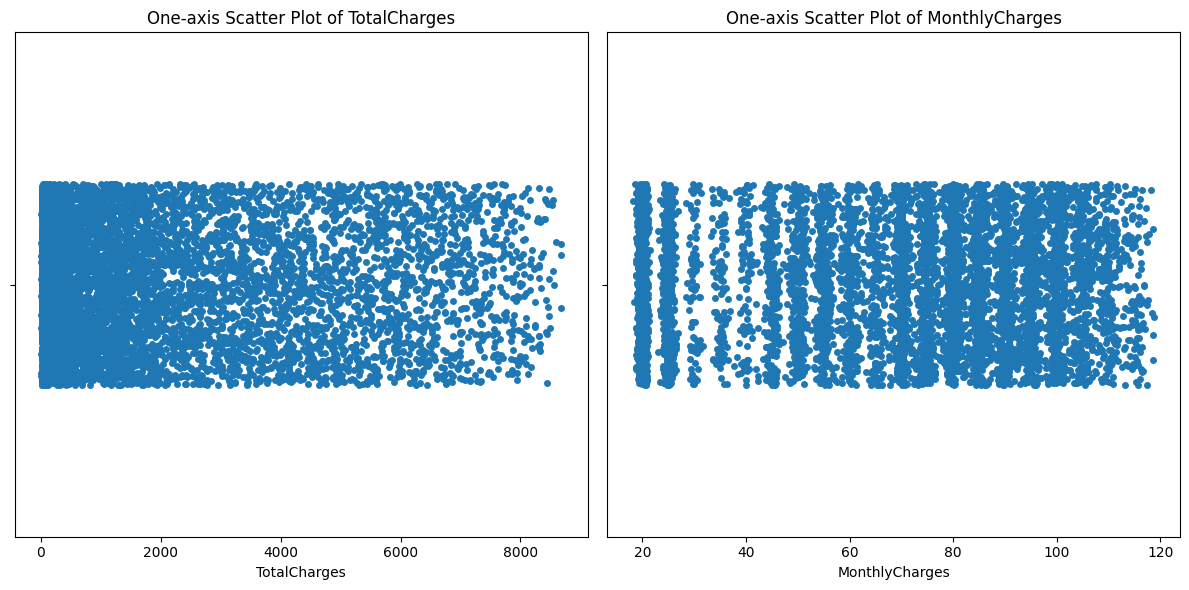

In [12]:
print(f"Range of TotalCharges: {df['TotalCharges'].min()} - {df['TotalCharges'].max()}")
print(f"Range of MonthlyCharges: {df['MonthlyCharges'].min()} - {df['MonthlyCharges'].max()}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.stripplot(x=df['TotalCharges'], jitter=0.2)
plt.title('One-axis Scatter Plot of TotalCharges')
plt.xlabel('TotalCharges')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.stripplot(x=df['MonthlyCharges'], jitter=0.2)
plt.title('One-axis Scatter Plot of MonthlyCharges')
plt.xlabel('MonthlyCharges')

plt.tight_layout()
plt.show()

Decision- we're going to normalize both values to [0,1],


Range of tenure: 0 - 72


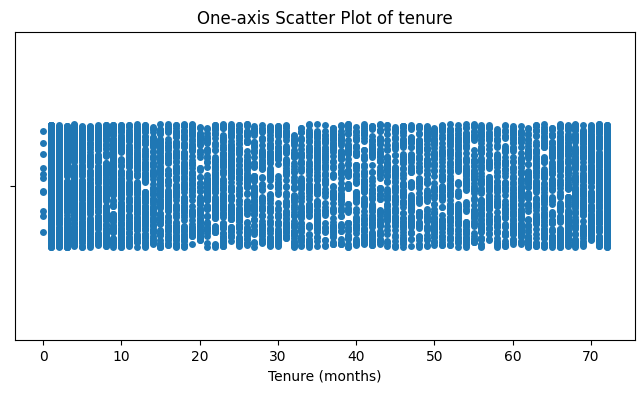

In [13]:
print(f"Range of tenure: {df['tenure'].min()} - {df['tenure'].max()}")

plt.figure(figsize=(8, 4))
sns.stripplot(x=df['tenure'], jitter=0.2)
plt.title('One-axis Scatter Plot of tenure')
plt.xlabel('Tenure (months)')
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

# Make a copy to work on, ensuring we don't accidentally modify other variables if not intended
df_processed = df_encoded.copy()

# 1. Normalize 'tenure', 'TotalCharges', 'MonthlyCharges'
numerical_cols_to_normalize = ['tenure', 'TotalCharges', 'MonthlyCharges']
scaler = StandardScaler()
df_processed[numerical_cols_to_normalize] = scaler.fit_transform(df_processed[numerical_cols_to_normalize])

# 2. One-hot encode 'SeniorCitizen'
# Since 'SeniorCitizen' is already 0 or 1, pd.get_dummies will treat these as categories.
df_processed = pd.get_dummies(df_processed, columns=['SeniorCitizen'], prefix='SeniorCitizen', drop_first=False)

print("DataFrame after normalization and one-hot encoding of SeniorCitizen:")
print(df_processed.head())
print(f"\nNew shape of DataFrame: {df_processed.shape}")
print("\nData types after processing:")
print(df_processed.dtypes.value_counts())

DataFrame after normalization and one-hot encoding of SeniorCitizen:
     tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  Partner_Yes  \
0 -1.277445       -1.160323     -0.992611      0        False         True   
1  0.066327       -0.259629     -0.172165      0         True        False   
2 -1.236724       -0.362660     -0.958066      1         True        False   
3  0.514251       -0.746535     -0.193672      0         True        False   
4 -1.236724        0.197365     -0.938874      1        False        False   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  \
0           False             False                            True   
1           False              True                           False   
2           False              True                           False   
3           False             False                            True   
4           False              True                           False   

   MultipleLines_Yes  ...  Streamin

#**Cleaning pipeline for shared usage with team**

In [25]:
def clean_data(raw_df):
    # 1. Create a copy to avoid SettingWithCopyWarning
    temp_df = raw_df.copy()

    # 2. Clean 'TotalCharges': convert to numeric and fill NaNs (from empty strings) with 0
    temp_df['TotalCharges'] = pd.to_numeric(temp_df['TotalCharges'], errors='coerce')
    temp_df['TotalCharges'] = temp_df['TotalCharges'].fillna(0)

    # 3. Drop 'customerID' if it exists
    if 'customerID' in temp_df.columns:
        temp_df = temp_df.drop('customerID', axis=1)

    # 4. Convert 'Churn' target to numerical (0/1) if it exists
    if 'Churn' in temp_df.columns:
        temp_df['Churn'] = temp_df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

    # 5. One-hot encode categorical string columns
    # We use drop_first=True to avoid redundant columns (the dummy variable trap)
    categorical_cols = [col for col in temp_df.columns if temp_df[col].dtype == 'object']
    if 'Churn' in categorical_cols: categorical_cols.remove('Churn')
    temp_df = pd.get_dummies(temp_df, columns=categorical_cols, drop_first=True)

    # 6. One-hot encode 'SeniorCitizen' (int-type)
    # We set drop_first=True here as well to avoid having both _0 and _1 columns
    if 'SeniorCitizen' in temp_df.columns:
        temp_df = pd.get_dummies(temp_df, columns=['SeniorCitizen'], prefix='SeniorCitizen', drop_first=True)

    # 7. Standardize numerical features
    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    scaler = StandardScaler()
    temp_df[numerical_cols] = scaler.fit_transform(temp_df[numerical_cols])

    return temp_df

# Re-load and test the updated pipeline
df_raw = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))
df_final = clean_data(df_raw)

display(df_final.head())
print(f"Updated pipeline complete. Final shape: {df_final.shape}")
print(f"Columns related to SeniorCitizen: {[c for c in df_final.columns if 'SeniorCitizen' in c]}")

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_1
0,-1.277445,-1.160323,-0.992611,0,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0.066327,-0.259629,-0.172165,0,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,-1.236724,-0.362660,-0.958066,1,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
3,0.514251,-0.746535,-0.193672,0,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,-1.236724,0.197365,-0.938874,1,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False


Updated pipeline complete. Final shape: (7043, 31)
Columns related to SeniorCitizen: ['SeniorCitizen_1']


**Assumption Testing**

### Test 1: **Linearity** (failed)

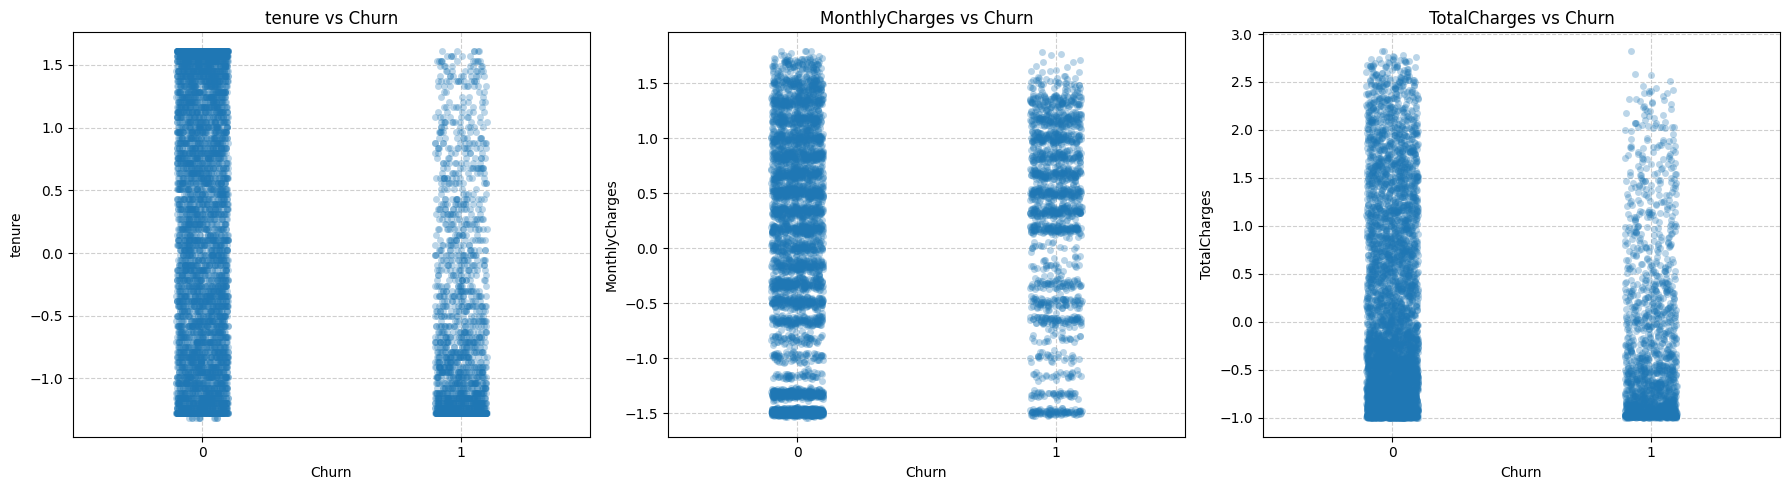

In [26]:
# Linearity check for numerical features vs Target (Churn)
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18, 5))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    # Use stripplot to visualize distribution density against the binary target
    sns.stripplot(x='Churn', y=col, data=df_final, alpha=0.3, jitter=True)
    plt.title(f'{col} vs Churn')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

commentary: if linearity was satisfied, we'd roughly see a smooth transition in intensity from 0 to 1... we do not.

**Test 2: Independent Observations**

Test 2.1: Association Between Categorical Variables (Cramér's V)
To check if categorical variables are redundant (highly associated), we calculate Cramér's V. A value of 1 indicates a perfect association, while 0 indicates no association.

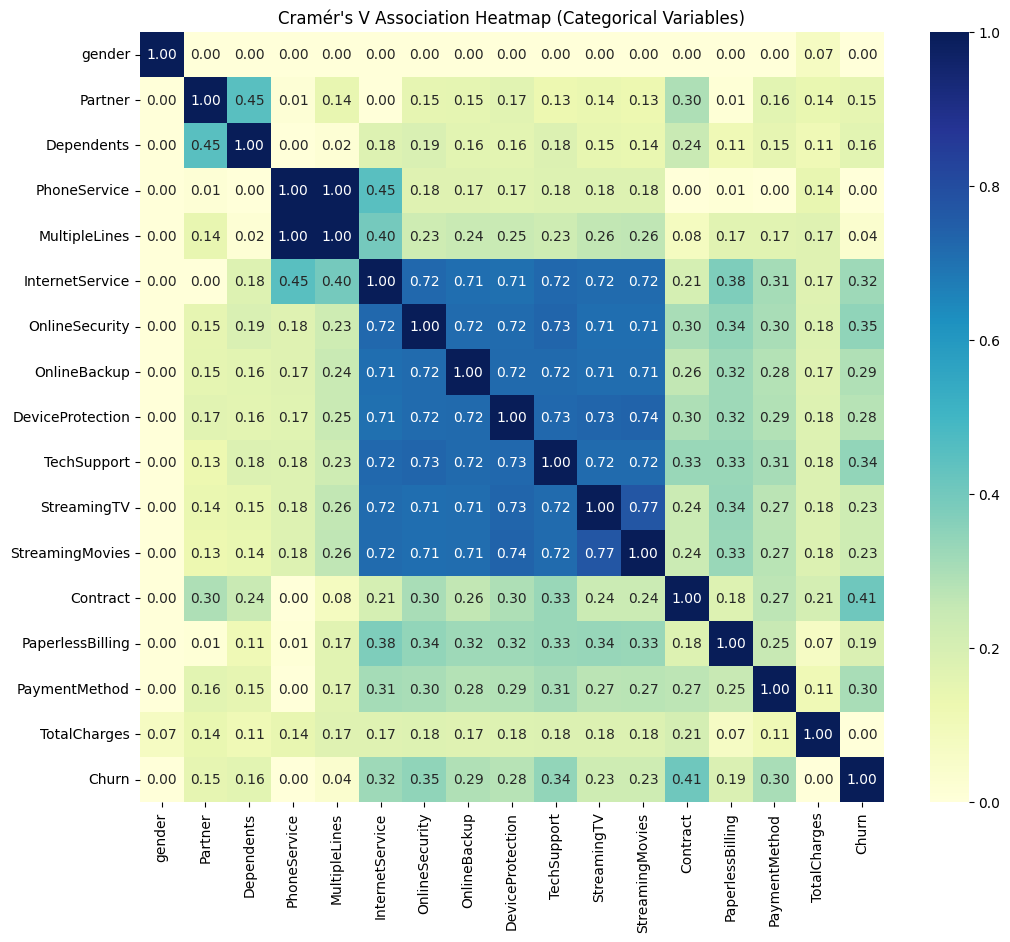

In [27]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """ Calculate Cramér's V statistic for categorical-categorical association. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Identify categorical columns from the raw data
cat_cols = [col for col in df_raw.columns if df_raw[col].dtype == 'object' and col != 'customerID']

# Initialize association matrix
assoc_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        assoc_matrix.loc[col1, col2] = cramers_v(df_raw[col1], df_raw[col2])

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(assoc_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Cramér's V Association Heatmap (Categorical Variables)")
plt.show()

### Identifying High Categorical Associations (Threshold > 0.70)
We will filter the Cramér's V matrix to find pairs that are highly redundant.

In [31]:
# Get pairs with Cramér's V > 0.70 (excluding self-correlation)
threshold = 0.70
high_assoc = []

for i in range(len(assoc_matrix.columns)):
    for j in range(i + 1, len(assoc_matrix.columns)):
        val = assoc_matrix.iloc[i, j]
        if val > threshold:
            high_assoc.append((assoc_matrix.columns[i], assoc_matrix.columns[j], val))

# Display findings
if high_assoc:
    print(f"Pairs with Cramér's V > {threshold}:")
    for pair in high_assoc:
        print(f"- {pair[0]} & {pair[1]}: {pair[2]:.2f}")
else:
    print(f"No categorical pairs found with association > {threshold}")

Pairs with Cramér's V > 0.7:
- PhoneService & MultipleLines: 1.00
- InternetService & OnlineSecurity: 0.72
- InternetService & OnlineBackup: 0.71
- InternetService & DeviceProtection: 0.71
- InternetService & TechSupport: 0.72
- InternetService & StreamingTV: 0.72
- InternetService & StreamingMovies: 0.72
- OnlineSecurity & OnlineBackup: 0.72
- OnlineSecurity & DeviceProtection: 0.72
- OnlineSecurity & TechSupport: 0.73
- OnlineSecurity & StreamingTV: 0.71
- OnlineSecurity & StreamingMovies: 0.71
- OnlineBackup & DeviceProtection: 0.72
- OnlineBackup & TechSupport: 0.72
- OnlineBackup & StreamingTV: 0.71
- OnlineBackup & StreamingMovies: 0.71
- DeviceProtection & TechSupport: 0.73
- DeviceProtection & StreamingTV: 0.73
- DeviceProtection & StreamingMovies: 0.74
- TechSupport & StreamingTV: 0.72
- TechSupport & StreamingMovies: 0.72
- StreamingTV & StreamingMovies: 0.77


### Strategy: Feature Selection via Target Association
To resolve redundancy between categorical variables while preserving predictive power, we will:
1. Calculate the association (Cramér's V) of every feature with the target variable `Churn`.
2. In each pair exceeding the 0.70 threshold, we will drop the feature that is less associated with `Churn`.

In [36]:
# 1. Calculate association of each category with the target 'Churn'
target_assoc = {}
for col in cat_cols:
    if col != 'Churn':
        target_assoc[col] = cramers_v(df_raw[col], df_raw['Churn'])

# 2. Identify which to drop based on the 'high_assoc' list previously calculated
drops = set()
for feat1, feat2, val in high_assoc:
    # Only process if we haven't already decided to drop one of them
    if feat1 not in drops and feat2 not in drops:
        score1 = target_assoc.get(feat1, 0)
        score2 = target_assoc.get(feat2, 0)

        # Drop the one with the weaker relationship to Churn
        if score1 < score2:
            drops.add(feat1)
        else:
            drops.add(feat2)

print(f"Based on association with Churn, we will drop: {list(drops)}")

# Apply the strategy to our encoded dataframe
# We need to drop all one-hot columns derived from these original features
columns_to_remove = [col for col in df_final.columns if any(d + '_' in col for d in drops)]
df_final_refined = df_final.drop(columns=columns_to_remove)

print(f"Removed {len(columns_to_remove)} one-hot columns. Remaining columns: {df_final_refined.shape[1]}")
display(df_final_refined.head())

Based on association with Churn, we will drop: ['InternetService', 'OnlineBackup', 'TechSupport', 'PhoneService', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']
Removed 13 one-hot columns. Remaining columns: 18


,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_1
0,-1.277445,-1.160323,-0.992611,0,False,True,False,True,False,False,False,False,False,True,False,True,False,False
1,0.066327,-0.259629,-0.172165,0,True,False,False,False,False,False,True,True,False,False,False,False,True,False
2,-1.236724,-0.362660,-0.958066,1,True,False,False,False,False,False,True,False,False,True,False,False,True,False
3,0.514251,-0.746535,-0.193672,0,True,False,False,True,False,False,True,True,False,False,False,False,False,False
4,-1.236724,0.197365,-0.938874,1,False,False,False,False,False,False,False,False,False,True,False,True,False,False


### Test 2.2: Multicollinearity (Numerical Autocorrelation)
We check the correlation between our numerical features to ensure they aren't providing redundant information.

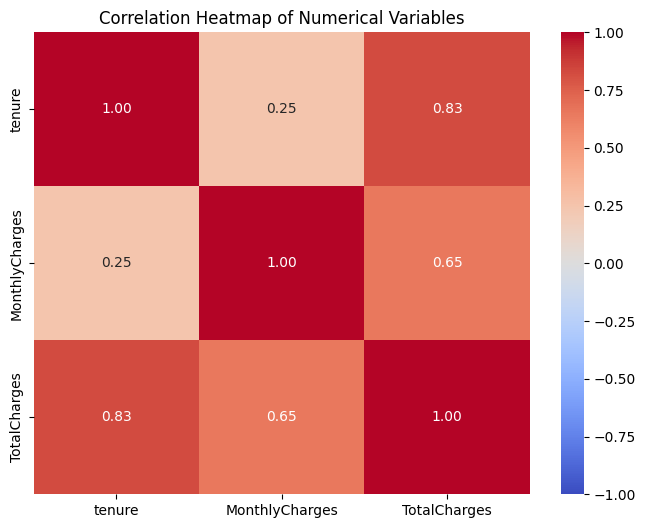

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_final[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### Final Feature Selection
We will drop `TotalCharges` to address the high numerical correlation with `tenure` before training.

In [37]:
# Drop TotalCharges as decided
if 'TotalCharges' in df_final_refined.columns:
    df_final_refined = df_final_refined.drop(columns=['TotalCharges'])

print(f"Final feature count: {df_final_refined.shape[1] - 1}")
display(df_final_refined.head())


Final feature count: 16


,tenure,MonthlyCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_1
0,-1.277445,-1.160323,0,False,True,False,True,False,False,False,False,False,True,False,True,False,False
1,0.066327,-0.259629,0,True,False,False,False,False,False,True,True,False,False,False,False,True,False
2,-1.236724,-0.362660,1,True,False,False,False,False,False,True,False,False,True,False,False,True,False
3,0.514251,-0.746535,0,True,False,False,True,False,False,True,True,False,False,False,False,False,False
4,-1.236724,0.197365,1,False,False,False,False,False,False,False,False,False,True,False,True,False,False


### Train-Test Split and Model Fitting
We'll use an 80/20 split with `random_state=42` and `stratify=y` to ensure consistent churn proportions.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define X and y
X = df_final_refined.drop('Churn', axis=1)
y = df_final_refined['Churn']

# Perform 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and fit Linear Regression
lpm_model = LinearRegression()
lpm_model.fit(X_train, y_train)

print("Model training complete.")
print(f"R-squared on training set: {lpm_model.score(X_train, y_train):.4f}")

Model training complete.
R-squared on training set: 0.2691


### Test 2.3: Independence of Observations (Durbin-Watson)
We calculate the residuals (actual - predicted) and use the Durbin-Watson statistic to check for autocorrelation. A value near 2.0 suggests the independence assumption is satisfied.

In [41]:
from statsmodels.stats.stattools import durbin_watson

# Calculate residuals from the training data
y_train_pred = lpm_model.predict(X_train)
residuals = y_train - y_train_pred

# Compute Durbin-Watson statistic
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")

# Interpretation
if 1.5 <= dw_stat <= 2.5:
    print("Conclusion: The statistic is near 2, indicating no significant autocorrelation in residuals. Independence assumption holds.")
else:
    print("Warning: Durbin-Watson statistic indicates potential autocorrelation.")

Durbin-Watson statistic: 2.0015
Conclusion: The statistic is near 2, indicating no significant autocorrelation in residuals. Independence assumption holds.


In [42]:
import numpy as np
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

# Continuous predictions from the LPM
y_test_pred = lpm_model.predict(X_test)

print("=== Regression metrics (test set) ===")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"R^2  : {r2_score(y_test, y_test_pred):.4f}")
print(f"R^2 (train, for comparison): {lpm_model.score(X_train, y_train):.4f}")

# LPM sanity check: fitted values outside [0,1] aren't valid probabilities
out_of_range = ((y_test_pred < 0) | (y_test_pred > 1)).mean()
print(f"\nPredictions outside [0,1]: {out_of_range:.1%} "
      f"(min={y_test_pred.min():.3f}, max={y_test_pred.max():.3f})")

# Threshold at 0.5 to get class labels
y_test_label = (y_test_pred >= 0.5).astype(int)

print("\n=== Classification metrics (threshold = 0.5) ===")
print(f"Accuracy : {accuracy_score(y_test, y_test_label):.4f}")
print(f"Precision: {precision_score(y_test, y_test_label, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_label, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test, y_test_label, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_pred):.4f}")

# Always-predict-majority-class baseline, for context
print(f"\nMajority-class baseline accuracy: {max(y_test.mean(), 1 - y_test.mean()):.4f}")

print("\nConfusion matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_test_label),
                   index=['actual: no churn', 'actual: churn'],
                   columns=['pred: no churn', 'pred: churn']))

print("\n" + classification_report(y_test, y_test_label,
                                   target_names=['No churn', 'Churn'],
                                   zero_division=0))

=== Regression metrics (test set) ===
RMSE : 0.3815
MAE  : 0.3133
R^2  : 0.2537
R^2 (train, for comparison): 0.2691

Predictions outside [0,1]: 16.2% (min=-0.213, max=0.785)

=== Classification metrics (threshold = 0.5) ===
Accuracy : 0.7963
Precision: 0.6593
Recall   : 0.4813
F1       : 0.5564
ROC-AUC  : 0.8325

Majority-class baseline accuracy: 0.7346

Confusion matrix:
                  pred: no churn  pred: churn
actual: no churn             942           93
actual: churn                194          180

              precision    recall  f1-score   support

    No churn       0.83      0.91      0.87      1035
       Churn       0.66      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



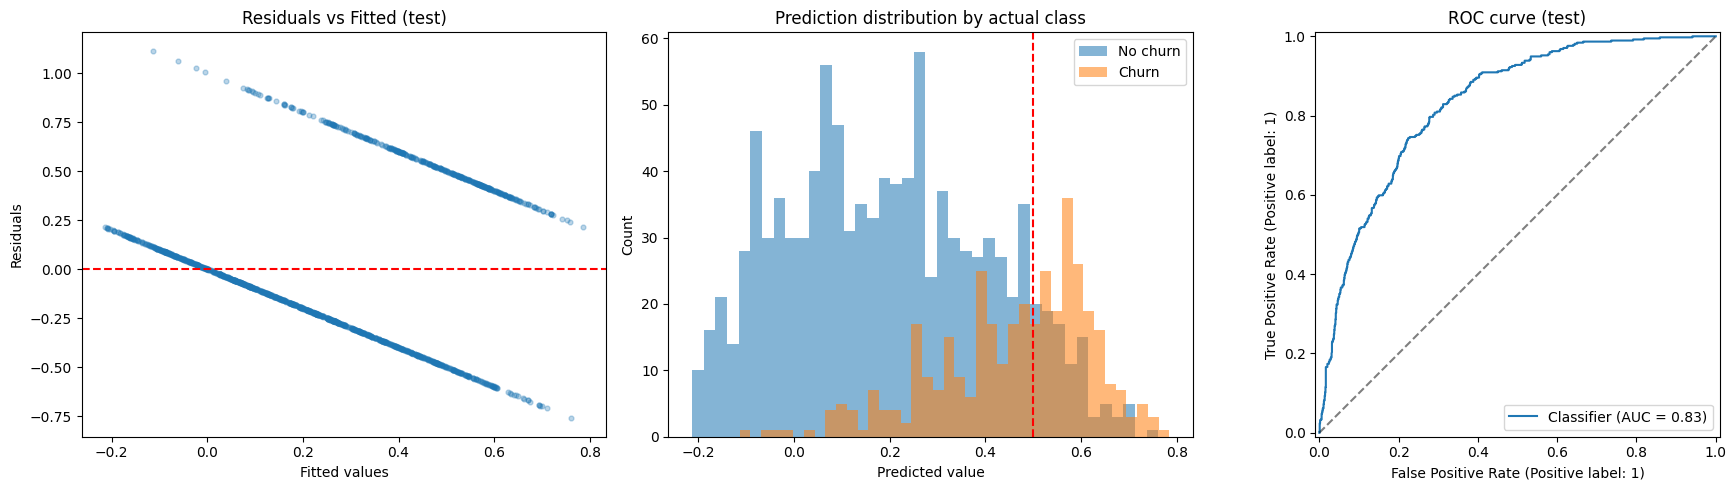

,feature,coefficient
9,Contract_One year,-0.136709
0,tenure,-0.121322
8,OnlineSecurity_Yes,-0.109609
10,Contract_Two year,-0.105212
1,MonthlyCharges,0.102086
13,PaymentMethod_Electronic check,0.097159
5,MultipleLines_No phone service,0.092726
11,PaperlessBilling_Yes,0.054667
15,SeniorCitizen_1,0.046600
6,MultipleLines_Yes,0.033518


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals_test = y_test - y_test_pred
axes[0].scatter(y_test_pred, residuals_test, alpha=0.3, s=12)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Fitted values', ylabel='Residuals',
            title='Residuals vs Fitted (test)')

for label, name in [(0, 'No churn'), (1, 'Churn')]:
    axes[1].hist(y_test_pred[y_test == label], bins=40, alpha=0.55, label=name)
axes[1].axvline(0.5, color='red', linestyle='--')
axes[1].set(xlabel='Predicted value', ylabel='Count',
            title='Prediction distribution by actual class')
axes[1].legend()

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_test_pred, ax=axes[2])
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('ROC curve (test)')

plt.tight_layout()
plt.show()

# Largest-magnitude coefficients
coef_df = (pd.DataFrame({'feature': X_train.columns, 'coefficient': lpm_model.coef_})
           .sort_values('coefficient', key=abs, ascending=False))
display(coef_df.head(15))

**Coefficient Interpretation**
- Based on the 18 variables we ended up keeping, for this particular split of the data, we can view the categorical variables as contributing absolutely to the "probability of churn" by the magnitude of the coefficient. So if they have online secruity (OnlineSecurity=1), that translates to a -13.67% predicted probability of a customer churning. Each coefficient has this same effect (as this is a linear probability model for 2 outcomes)

- For the numerical vars, b/c we standardized, the translation from one unit -> change in predicted porbability is the same, but the unit is a standard deviation, not the absolute value of the number.